 https://chemcoord.readthedocs.io/en/v2.0.5/src_Cartesian/src_Cartesian/chemcoord.Cartesian.get_grad_zmat.html#chemcoord.Cartesian.get_grad_zmat

In [17]:
%matplotlib inline 
import matplotlib.pyplot as plt
import torch
import numpy as np
import pandas as pd
import chemcoord as cc
from ase.io import Trajectory

from flonacomldft.utils.silver_isomers_utils import get_construction_table
from flonacomldft.utils.io_utils import get_path
from flonacomldft.internal_coordinates import (
    add_phase,
    Coordinates_mapping,
    save_internal_coordinates_to_csv
)

# 1 - Basic test of centering

In [18]:
traj_is1 = Trajectory(get_path() + 'md_trajectories/' + 'ag6_is1_lcao.traj')

In [41]:
coord_maps = Coordinates_mapping()
xs_is1 = coord_maps.get_internal_from_trajectory(traj_is1, temperature=300, max_samples=500)
xs_is1 = xs_is1.detach()
# xs_is1[:, 11][xs_is1[:, 11]>0] = xs_is1[:, 11][xs_is1[:, 11]>0].apply_(add_phase)

In [42]:
xs_is1.shape

torch.Size([501, 14])

In [43]:
coord_maps.zmat_minima

{0: tensor([ 2.7802,  2.6824,  2.7860,  2.6847,  2.6874,  1.0257,  2.0728,  2.0717,
          1.0218,  0.0000,  0.0000, -3.1416]),
 1: tensor([ 2.8166,  2.6839,  4.5685,  2.8162,  2.8166,  1.0191,  0.5528,  0.6248,
          1.2548,  1.8783,  2.1455, -1.0236])}

In [44]:
x_is1_min = coord_maps.zmat_minima[0]
x_is1_min.shape

torch.Size([12])

In [45]:
xs_is1[:, 0]

tensor([2.7808, 2.7856, 2.7903, 2.7947, 2.7987, 2.8023, 2.8053, 2.8077, 2.8095,
        2.8107, 2.8111, 2.8110, 2.8101, 2.8087, 2.8066, 2.8040, 2.8010, 2.7974,
        2.7935, 2.7892, 2.7847, 2.7800, 2.7753, 2.7705, 2.7659, 2.7615, 2.7575,
        2.7539, 2.7509, 2.7485, 2.7467, 2.7457, 2.7455, 2.7460, 2.7473, 2.7493,
        2.7520, 2.7553, 2.7591, 2.7632, 2.7677, 2.7722, 2.7768, 2.7812, 2.7854,
        2.7894, 2.7929, 2.7960, 2.7986, 2.8007, 2.8024, 2.8035, 2.8041, 2.8043,
        2.8041, 2.8034, 2.8023, 2.8009, 2.7990, 2.7968, 2.7942, 2.7912, 2.7878,
        2.7839, 2.7797, 2.7751, 2.7701, 2.7648, 2.7593, 2.7536, 2.7479, 2.7422,
        2.7368, 2.7317, 2.7270, 2.7229, 2.7196, 2.7169, 2.7152, 2.7143, 2.7144,
        2.7154, 2.7174, 2.7202, 2.7238, 2.7281, 2.7330, 2.7384, 2.7442, 2.7502,
        2.7564, 2.7626, 2.7688, 2.7748, 2.7807, 2.7862, 2.7914, 2.7963, 2.8008,
        2.8048, 2.8085, 2.8119, 2.8148, 2.8175, 2.8198, 2.8219, 2.8237, 2.8252,
        2.8265, 2.8275, 2.8284, 2.8290, 

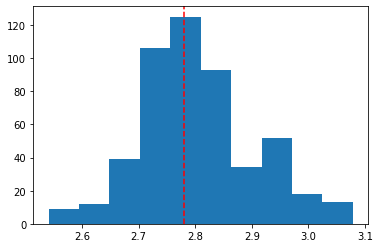

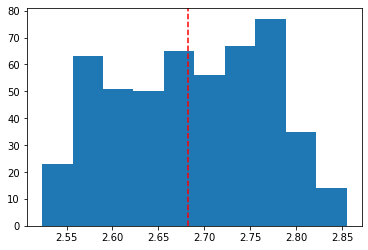

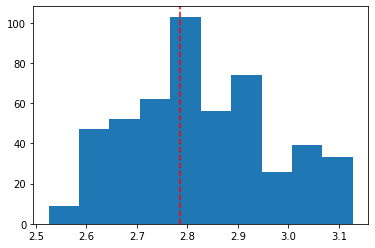

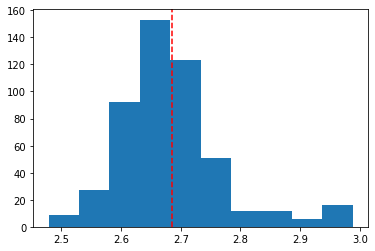

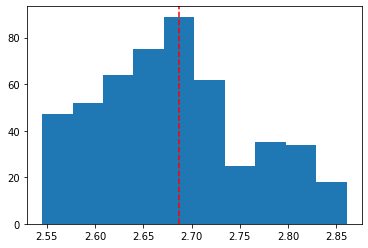

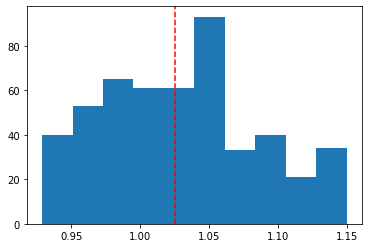

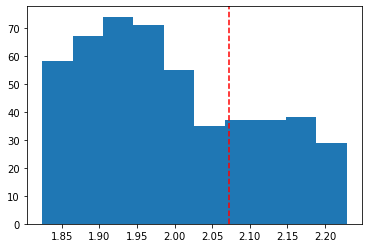

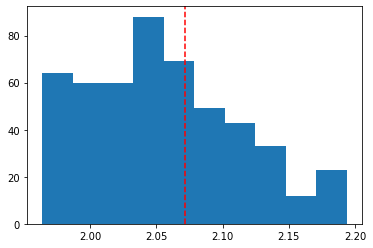

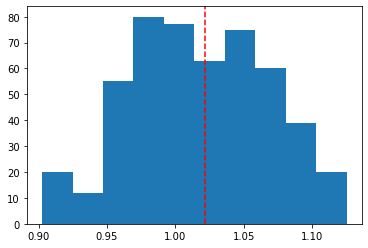

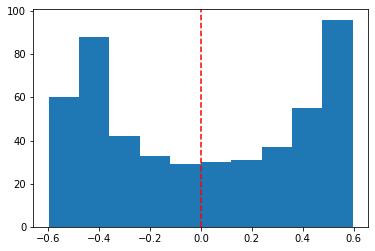

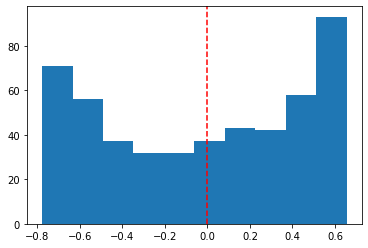

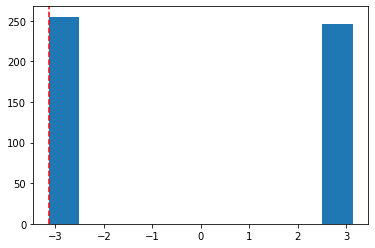

In [46]:
for i in range(12):
    plt.hist(xs_is1[:, i].numpy())
    plt.axvline(x_is1_min[i], color='r', linestyle='--')
    plt.show()

In [36]:
# xs_is1[:, 11][xs_is1[:, 11]>0] = xs_is1[:, 11][xs_is1[:, 11]>0].apply_(add_phase)

(array([ 5.,  4.,  4.,  4.,  7.,  7.,  9., 11., 16., 34.]),
 array([-3.1415927, -3.0956943, -3.0497959, -3.0038974, -2.957999 ,
        -2.9121003, -2.8662019, -2.8203034, -2.774405 , -2.7285066,
        -2.6826081], dtype=float32),
 <BarContainer object of 10 artists>)

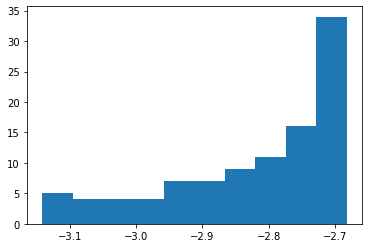

In [37]:
# plt.hist(xs_is1[:, 11].numpy())

In [47]:
logdetjacs = xs_is1[:,-2]
energies = xs_is1[:,-1]
xs_is1 = xs_is1[:,:-2]
xs_is1_real_centered, logdetjacs, energies = coord_maps.get_real_centered_from_internal(xs_is1, logdetjacs, isomer=0, energies=energies)

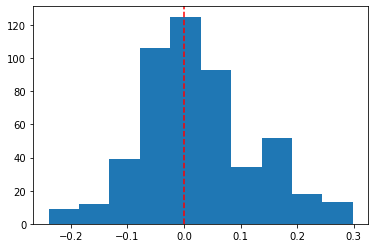

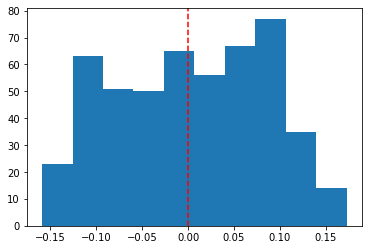

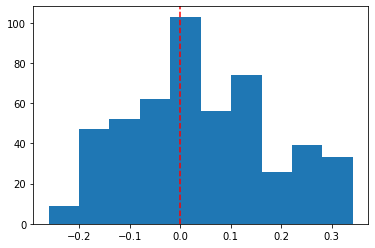

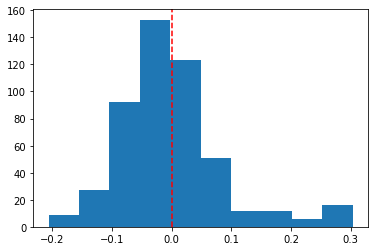

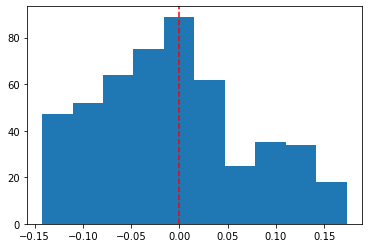

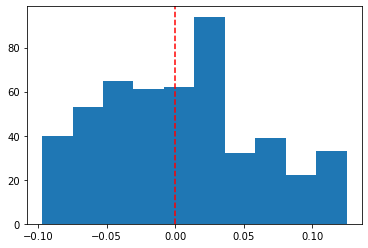

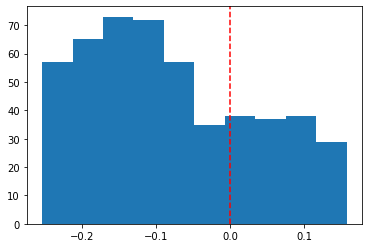

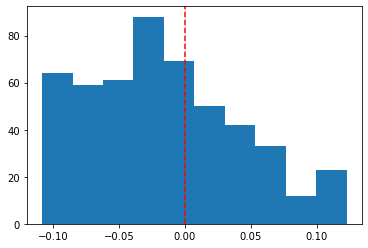

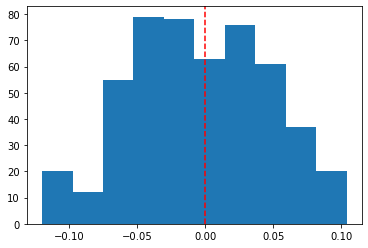

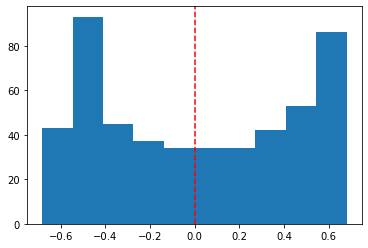

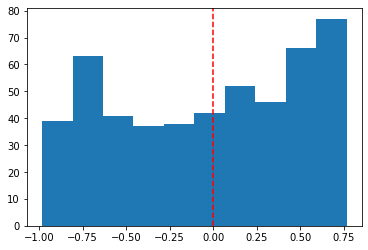

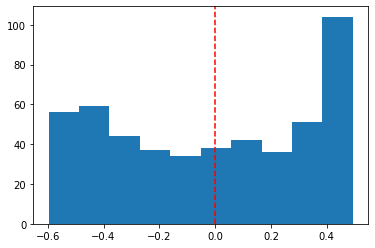

In [48]:
for i in range(12):
    plt.hist(xs_is1_real_centered[:, i].numpy())
    plt.axvline(0, color='r', linestyle='--')
    plt.show()

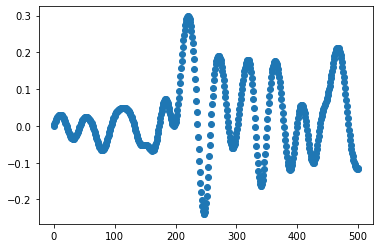

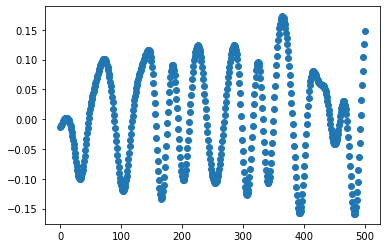

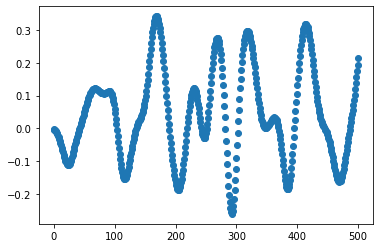

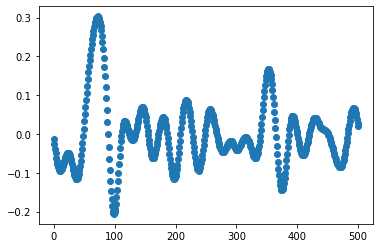

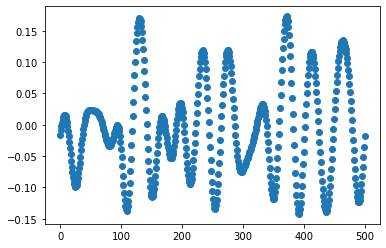

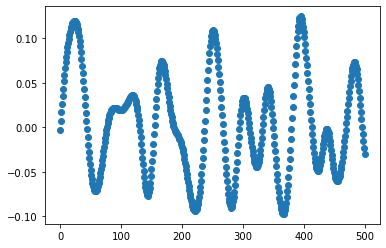

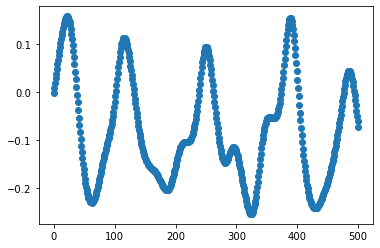

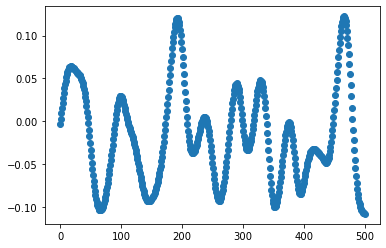

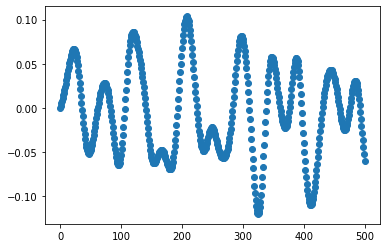

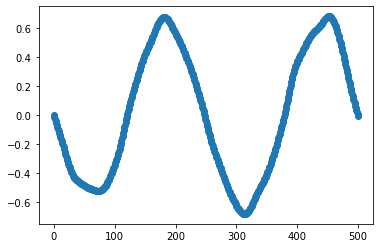

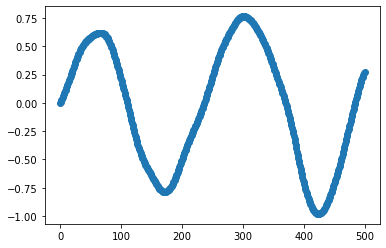

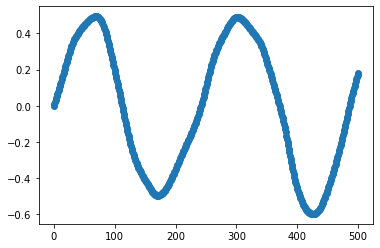

In [49]:
for i in range(12): 
    plt.figure()
    plt.plot(xs_is1_real_centered[:, i].numpy(), 'o')

## 1.2 testing isomer 2 - 3d

In [63]:
traj_is2 = Trajectory(get_path() + 'md_trajectories/' + 'ag6_is2_lcao.traj')
coord_maps = Coordinates_mapping()
xs_ldj_nrg_is2 = coord_maps.get_internal_from_trajectory(traj_is2, temperature=300, max_samples=500)

In [64]:
logdetjacs = xs_ldj_nrg_is2[:,-2]
energies = xs_ldj_nrg_is2[:,-1]
xs_is2 = xs_ldj_nrg_is2[:,:-2]
xs_is2_real_centered, logdetjacs, energies = coord_maps.get_real_centered_from_internal(xs_is2, logdetjacs, isomer=1, energies=energies)

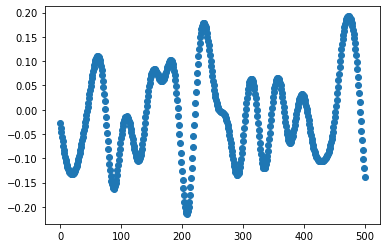

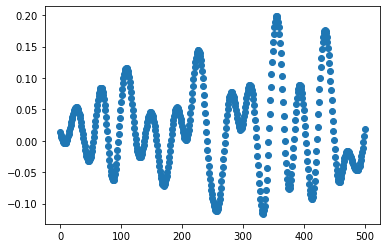

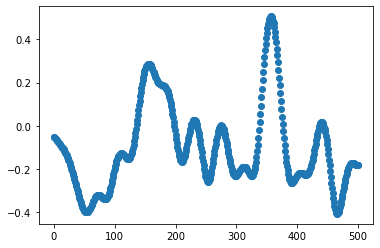

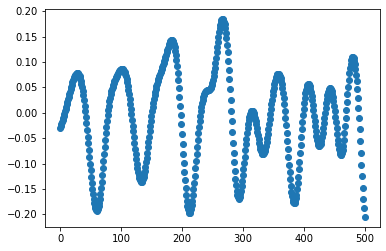

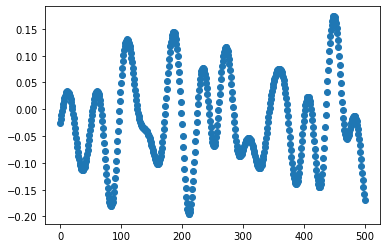

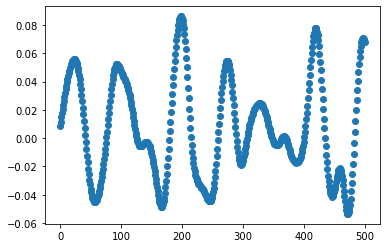

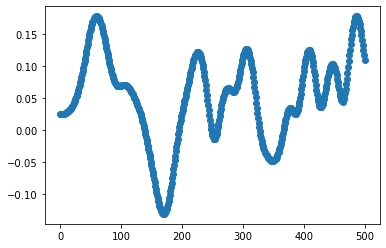

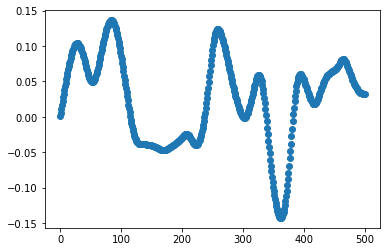

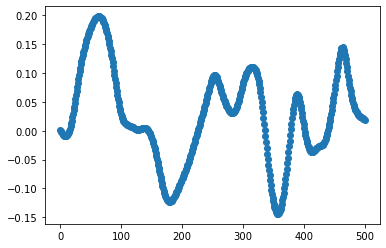

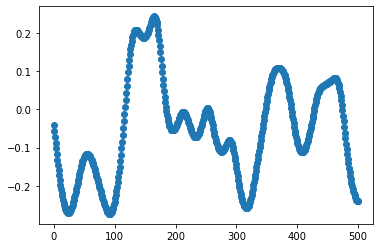

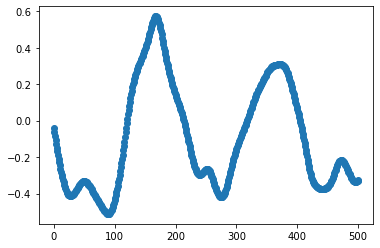

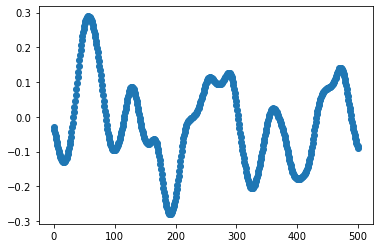

In [65]:
for i in range(12): 
    plt.figure()
    plt.plot(xs_is2_real_centered[:, i].numpy(), 'o')

# 2 - Using pre-saved internal coordinates + logdetjac

In [57]:
from flonacomldft.utils.io_utils import load_csv_file, get_path

xs_ldj_nrg_is1 = load_csv_file('int_coords/is1_lcao_zmat.csv')
xs_ldj_nrg_is2 = load_csv_file('int_coords/is2_lcao_zmat.csv')

logdetjacs = xs_ldj_nrg_is1[:,-2]
energies = xs_ldj_nrg_is1[:,-1]
xs_is1 = xs_ldj_nrg_is1[:,:-2]
xs_is1_real_centered, logdetjacs, energies = coord_maps.get_real_centered_from_internal(xs_is1, logdetjacs, isomer=0, energies=energies)

logdetjacs = xs_ldj_nrg_is2[:,-2]
energies = xs_ldj_nrg_is2[:,-1]
xs_is2 = xs_ldj_nrg_is2[:,:-2]
xs_is2_real_centered, logdetjacs, energies = coord_maps.get_real_centered_from_internal(xs_is2, logdetjacs, isomer=1, energies=energies)
